# 00 · 기초: 루프 엔지니어링이란 무엇이고, 무엇으로 측정할 것인가

이 시리즈는 **루프 엔지니어링(loop engineering)** 의 각 구성요소가 AI 시스템을 실제로 개선한다는 것을, 업계 표준 벤치마크에서 실측한 숫자로 증명한다. 원본 실험은 NVIDIA A100 80GB 한 장에 오픈 코딩 모델(Qwen2.5-Coder-32B-Instruct, AWQ 4비트)을 vLLM 으로 서빙해 수행했다.

한국어판은 여기에 더해 **OpenAI API 로도 전 과정을 완주할 수 있게** 확장했다. 노트북은 실행 환경을 스스로 판별하므로, GPU 서버든 노트북이든 첫 셀만 실행하면 알아서 맞는 백엔드를 잡는다.

이 노트북이 하는 일은 세 가지다.

1. 루프 엔지니어링이 어디에 위치하는지, 지렛점이 어떻게 옮겨 왔는지 설명한다.
2. 공유 엔진을 세우고 검증한다 — 모델 서버, 연산 장치, 그리고 **채점기**.
3. **단일 에이전트 베이스라인**을 확립한다. 이후 모든 노트북은 루프 엔지니어링 구성요소를 하나씩 더하고, 그것이 이 베이스라인을 얼마나 밀어올리는지 보여 준다.

In [2]:
# 서술용 다이어그램을 먼저 렌더하기 위한 최소 부트스트랩.
# 무거운 의존성(torch, datasets, vllm)은 아직 건드리지 않는다.
import os
import sys

# 노트북의 현재 작업 디렉토리가 어디든 프로젝트를 import 할 수 있게 만든다
sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))
from common import show


## 지렛점은 이동해 왔다: 프롬프트 → 컨텍스트 → 하네스 → 루프

엔지니어가 AI 코딩 에이전트에서 가치를 뽑아내는 방식은 단계적으로 옮겨 왔다.

- **프롬프트 엔지니어링(prompt engineering)** — 좋은 프롬프트 하나를 만들고 답을 읽는다.
- **컨텍스트 엔지니어링(context engineering)** — 한 번의 턴에 맞는 컨텍스트(파일·문서·예시)를 조립한다.
- **에이전트 하네스 엔지니어링(agent harness engineering)** — 에이전트 하나가 돌아가는 환경을 설계한다. 툴, 권한, 규칙.
- **루프 엔지니어링(loop engineering)** — 하네스 실행을 시간에 걸쳐 스케줄링하고 조율하는 시스템을 설계한다. 검증과 지속되는 상태를 포함해서.

직설적으로 말하면 이렇다.

> 루프 엔지니어링은 **에이전트에게 프롬프트를 넣는 사람이라는 자리에서 자신을 치우는 일**이다. 그 일을 대신할 시스템을 설계하는 것이다.

> 루프는 재귀적 목표다. 목적을 정의하면 에이전트가 (대개 서브에이전트·검증·외부 상태를 동원해) 목표가 완료되거나 사람에게 넘길 때까지 반복한다.

이 시리즈가 다루는 이동은, 에이전트 하나에 손으로 프롬프트를 넣던 방식에서 **에이전트를 대신 돌려 줄 루프를 설계하는 방식**으로의 전환이다.


*지렛점은 프롬프트에서 루프로 이동해 왔다*

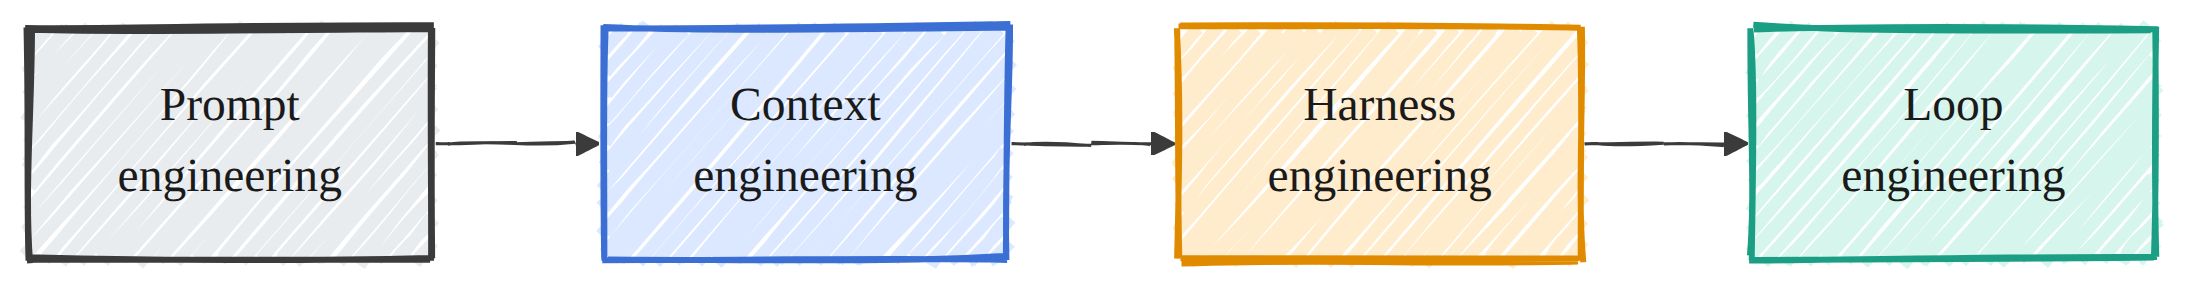

In [3]:
# 지렛점의 이동을 한 장으로. 손으로 그린 다이어그램을 인라인 렌더한다.
show.diagram("evolution", "지렛점은 프롬프트에서 루프로 이동해 왔다")


## 루프의 해부도

하나의 루프를 이런 순환으로 그린다.

```
스케줄 → 트리아지 스킬 → 상태/메모리 → 워크트리 → 구현자 → 검증기
       → MCP/Git/티켓 → 사람 게이트? → (실행 또는 에스컬레이션) → 다시 스케줄
```

여섯 개의 구성 블록에 메모리를 더하면 이렇게 된다 — 스케줄링, 워크트리, 스킬, 커넥터(MCP), 서브에이전트(생성자·검증자), 상태/메모리. 시리즈의 나머지는 각 블록을 하나씩 떼어내 기여분을 측정하고, 마지막에 캡스톤에서 다시 조립해 실제 GitHub 이슈를 해결한다.

| 구성요소 | 노트북 | 사용 벤치마크 |
|---|---|---|
| 스케줄링 + 완료까지 반복 | 01 | MBPP+ |
| 스킬 / 컨텍스트 | 02 | text-to-SQL (sql-create-context) |
| 서브에이전트 / 생성자-검증자 | 03 | MBPP+ |
| 메모리 / 상태 (RAG) | 04 | 프로젝트 지식베이스 |
| 워크트리 | 05 | 병렬 저장소 작업 |
| 커넥터 / 툴 | 06 | 생성된 데이터 분석 태스크 |
| 다중 루프 조율 | 07 | 동시 실행 루프 |
| 예산 / 비용 | 08 | 실측된 실행 기록 |
| 안전 / 가드레일 | 09 | 액션 라우팅 |
| 7가지 운영 패턴 | 10~16 | GitBugs, SATD, Vue 커밋, 구성된 시나리오 |
| 오케스트레이션 캡스톤 | 17 | SWE-bench-Verified-Mini |


*루프 하나의 해부: 스케줄 · 트리아지 · 상태 · 워크트리 · 구현 · 검증 · 게이트*

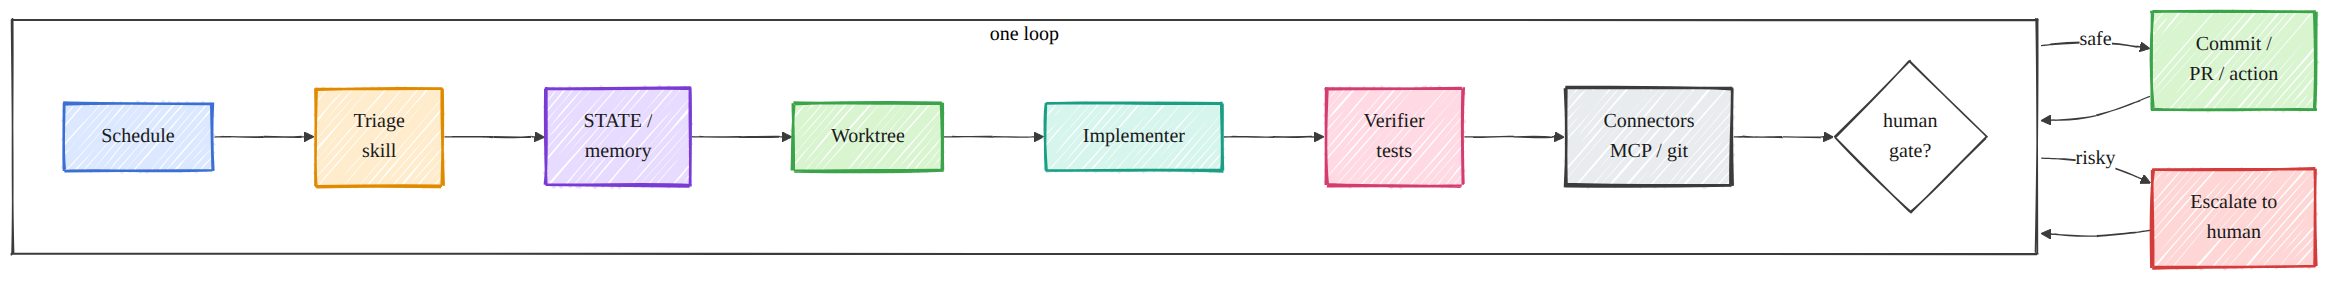

In [4]:
# 이 시리즈가 하나씩 분해해 측정할 루프의 전체 해부도
show.diagram("anatomy", "루프 하나의 해부: 스케줄 · 트리아지 · 상태 · 워크트리 · 구현 · 검증 · 게이트")


## 1단계: 엔진에 연결하고 경로를 잡는다

공유 유틸리티 `common` 을 임포트하고 모델 서버에 연결한다. `LLM` 클라이언트는 OpenAI 호환 엔드포인트를 감싸면서 **모든 호출의 토큰 사용량과 지연시간을 기록**하는데, 뒤에 나올 비용 비교가 정직할 수 있는 것은 이 계측 덕분이다.

한국어판에서는 여기에 자동 판별이 붙는다. `runtime.bootstrap()` 이 로컬 vLLM 이 떠 있는지 먼저 확인하고, 없으면 `OPENAI_API_KEY` 를 찾는다. 어느 쪽이 선택됐는지는 배너로 반드시 출력되므로, 내가 보는 수치가 어느 환경에서 나온 것인지 헷갈릴 일이 없다.


In [5]:
import os
import sys

# 노트북의 작업 디렉토리와 무관하게 프로젝트를 import 할 수 있게 한다
sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, eval as ev, agents, runtime
from common.llm import LLM
from common import runlog

# ── 실행 환경 자동 판별 ────────────────────────────────────────────
# 로컬 vLLM 이 떠 있으면 그것을, 없으면 OPENAI_API_KEY 를 찾아 API 를 쓴다.
# ⚠️ 함정: 키가 있다는 이유만으로 API 를 먼저 잡지 않는다. 로컬이 살아 있으면
#    로컬이 이긴다. 사용자가 모르는 사이에 과금되는 상황을 막기 위해서다.
#    강제로 바꾸려면  os.environ["LLM_PROVIDER"] = "openai"  를 이 줄 위에 둔다.
rt = runtime.bootstrap()

show.head("Environment")
show.kv("LEN_PROJECT_ROOT", os.environ.get("LEN_PROJECT_ROOT", "(unset)"))
show.kv("provider", rt.llm.provider)

# LLM() 은 인자가 없으면 위에서 판별된 설정을 그대로 받아 쓴다.
# 노트북 코드가 백엔드에 대해 아무것도 몰라도 되는 것이 이 설계의 핵심이다.
llm = LLM()
health = llm.health()          # 실제로 한 번 생성해 본다. 소켓만 열리는 것과 다르다.
show.sub("엔진 health")
show.show_dict(health, "")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  ⚠️  원본 코스의 수치는 Qwen2.5-Coder-32B(vLLM) 기준이다. API 모델에서는 값이 다를 수 있다.
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=========================================== Environment ============================================
  LEN_PROJECT_ROOT:          (unset)
  provider:                  openai

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2


------------------------------------------- vLLM health --------------------------------------------
{
  "model": "Qwen/Qwen2.5-Coder-32B-Instruct-AWQ",
  "base_url": "http://localhost:8000/v1",
  "reply": "ready"
}


## 2단계: 연산 장치 확인

원본 시리즈는 실제 GPU 를 전제한다. `nvidia-smi` 를 출력해 어떤 카드와 드라이버가 이 결과를 만들었는지를 저장된 출력에 기록해 둔다.

한국어판에서는 이 셀이 조건부다. GPU 가 있으면 원본과 동일하게 상세 정보를 찍고, 없으면 건너뛴다. **원본은 `import torch` 를 무조건 실행해 CPU 환경에서 여기서 즉시 죽는다.** API 모드로 학습하는 사람이 3번째 셀에서 막히지 않도록 고친 부분이다.


In [6]:
show.head("연산 장치")

# ⚠️ 함정: 원본은 이 셀에서 nvidia-smi 와 import torch 를 무조건 실행한다.
#    GPU 없는 환경에서는 여기서 노트북이 끝난다. 조건부로 바꾼 이유다.
if rt.embed.device == "cuda" or rt.llm.provider == "vllm":
    import subprocess

    try:
        out = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,driver_version,memory.total,memory.used",
             "--format=csv"],
            capture_output=True, text=True, timeout=30,
        ).stdout
        print(out.strip())
    except Exception as e:
        print("nvidia-smi 실행 실패:", e)

    try:
        import torch  # noqa: E402

        show.kv("torch", torch.__version__)
        show.kv("cuda runtime", torch.version.cuda)
        show.kv("cuda available", torch.cuda.is_available())
        show.kv("device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
    except ImportError:
        print("torch 미설치 — API 경로에서는 필요 없다")
else:
    # API 모드: GPU 가 없는 것이 정상이므로 실패가 아니라 정보로 표시한다
    print("GPU 없음 — API 모드로 실행 중이다.")
    show.kv("LLM", f"{rt.llm.provider} / {rt.llm.model}")
    show.kv("임베딩", f"{rt.embed.provider} / {rt.embed.model}")
    print("\n아래 저장된 출력은 원본 실험 환경(A100 80GB)의 기록이다.")



============================================== 연산 장치 ===============================================
GPU 없음 — API 모드로 실행 중이다.
  LLM:                       openai / gpt-5.6-luna
  임베딩:                       openai / text-embedding-3-small

아래 저장된 출력은 원본 실험 환경(A100 80GB)의 기록이다.


  torch:                     2.11.0+cu130
  cuda runtime:              13.0
  cuda available:            True
  device:                    NVIDIA A100 80GB PCIe


## 3단계: 어떤 결과를 믿기 전에, 채점기부터 믿을 수 있어야 한다

이 시리즈의 모든 pass@1 과 실행 정확도는 `common.eval` 에서 나온다. **채점기가 틀리면 그 아래의 모든 주장이 틀린다.** 그래서 무엇을 측정하기 전에 채점기의 자체 테스트를 먼저 돌린다. 정답임이 알려진 해답과 오답임이 알려진 해답을 각 검사기에 넣고, 기대대로 채점되는지 단언한다. 무한 루프가 멈추지 않고 매달리는 대신 타임아웃에 걸리는지까지 포함해서다.


In [7]:
show.head("채점기 자체 테스트")

# 이 시리즈의 모든 숫자가 여기서 나온다. 계측기를 먼저 교정하는 셀이다.
st = ev.self_test()
show.show_dict(st, "")

# ⚠️ 함정: 이 단언을 주석 처리하고 진행하고 싶어지는 순간이 온다.
#    그러면 이후의 모든 수치가 의미를 잃는다. 채점기가 깨졌으면 멈추는 것이 맞다.
assert st["all_passed"], "채점기 자체 테스트 실패 — 이후 수치를 신뢰하지 말 것"
print("\n채점기는 신뢰할 수 있다: 정답은 통과하고, 오답은 실패한다.")



============================================ 채점기 자체 테스트 ============================================
{
  "check_io": {
    "good_all_pass": true,
    "bad_all_pass": false
  },
  "check_asserts": {
    "good": true,
    "bad": false
  },
  "timeout_caught": true,
  "pass_at_k": {
    "n5_c1_k1": 0.2
  },
  "similarity": {
    "em": true,
    "edit": 0.75
  },
  "sql_exec_match": {
    "same": true,
    "diff": false
  },
  "ir_metrics": true,
  "all_passed": true
}

채점기는 신뢰할 수 있다: 정답은 통과하고, 오답은 실패한다.


{
  "check_io": {
    "good_all_pass": true,
    "bad_all_pass": false
  },
  "check_asserts": {
    "good": true,
    "bad": false
  },
  "timeout_caught": true,
  "pass_at_k": {
    "n5_c1_k1": 0.2
  },
  "similarity": {
    "em": true,
    "edit": 0.75
  },
  "sql_exec_match": {
    "same": true,
    "diff": false
  },
  "ir_metrics": true,
  "all_passed": true
}

Scorer is trustworthy: known-good solutions pass, known-bad solutions fail.


## 4단계: 작은 스모크셋 적재

00번은 실제 코딩 과제로 이루어진 아주 작은 내장 세트(함수+테스트 형태, 그리고 표준입출력 프로그램 하나)를 쓴다. 목적은 오직 하나 — **파이프라인 전체를 끝에서 끝까지 검증하는 것**이다. 모델에 프롬프트를 넣고, 코드를 추출하고, 테스트를 돌리고, 채점한다. 어려운 벤치마크는 다음 노트북부터 등장한다.


In [8]:
from common import data  # noqa: E402

problems = data.load_smoke()
show.head(f"스모크셋: 문제 {len(problems)}개")

for p in problems:
    show.sub(p.id)
    # kind 가 두 가지인 것이 핵심이다. asserts 와 io 는 서로 다른 채점 경로를 탄다.
    show.kv("kind", p.kind)
    show.kv("entry_point", p.entry_point or "(표준입출력 프로그램)")
    show.text(p.prompt, "prompt", max_chars=300)



=========================================== 스모크셋: 문제 5개 ============================================

-------------------------------------- smoke/two_sum_indices ---------------------------------------
  kind:                      asserts
  entry_point:               first_pair_summing

---------------------------------------------- prompt ----------------------------------------------
Write a Python function `first_pair_summing(nums, target)` that returns a tuple (i, j) with i < j of the first pair of indices whose values sum to target, scanning j from left to right and i before it. Return None if no pair exists.

--------------------------------------- smoke/is_palindrome ----------------------------------------
  kind:                      asserts
  entry_point:               is_palindrome

---------------------------------------------- prompt ----------------------------------------------
Write a Python function `is_palindrome(s)` that returns True if s reads the same forwards an

## 5단계: 단일 에이전트 베이스라인

이후의 모든 구성요소가 이겨야 할 기준선이다. 베이스라인은 가능한 한 가장 단순한 것이다 — **모델에게 한 번 묻고(탐욕적, temperature 0), 그 코드를 받아, 테스트를 돌린다.** 반복 없음, 검증기 없음, 메모리 없음, 툴 없음.

첫 문제에 대해서는 모든 단계를 출력해 데이터 흐름이 눈에 보이게 하고, 그다음 전체 세트를 돌려 pass@1 을 계산한다.


In [9]:
show.head("베이스라인: 문제당 탐욕적 시도 1회")

# ── 첫 문제로 전체 흐름을 눈으로 따라간다 ──────────────────────────
p0 = problems[0]
show.sub(f"{p0.id} 단계별 추적")

prompt0 = agents.solve_prompt(p0)
show.text(prompt0, "모델에 보낸 prompt", max_chars=500)

# temperature=0.0 으로 고정하는 이유: 루프의 기여분을 재려면 샘플링 분산이
# 섞이면 안 된다. 베이스라인이 흔들리면 나중의 '개선' 이 개선인지 잡음인지 모른다.
code0, gen0 = agents.single_shot(llm, p0, temperature=0.0)
show.code(code0, "모델이 낸 코드 (펜스에서 추출)")

# 채점은 모델 의견이 아니라 실제 실행이다.
# ⚠️ 함정: 여기서 모델의 자기평가를 쓰면 03번에서 보듯 오수용률이 77% 까지 오른다.
res0 = agents.grade(p0, code0)
show.show_dict(res0, "채점 결과")
show.kv("correct", agents.is_correct(res0))
show.kv("토큰 (prompt/completion)", f"{gen0.prompt_tokens}/{gen0.completion_tokens}")



======================================= 베이스라인: 문제당 탐욕적 시도 1회 =======================================

----------------------------------- smoke/two_sum_indices 단계별 추적 -----------------------------------

------------------------------------------ 모델에 보낸 prompt -------------------------------------------
Implement the function described below. Return only one python code block with the complete function plus any imports or helpers it needs.

Write a Python function `first_pair_summing(nums, target)` that returns a tuple (i, j) with i < j of the first pair of indices whose values sum to target, scanning j from left to right and i before it. Return None if no pair exists.

---------------------------------------- 모델이 낸 코드 (펜스에서 추출) ----------------------------------------
  | def first_pair_summing(nums, target):
  |     for j in range(len(nums)):
  |         for i in range(j):
  |             if nums[i] + nums[j] == target:
  |                 return i, j
  |     return None

----------


-------------------------------------- model's extracted code --------------------------------------
  | def first_pair_summing(nums, target):
  |     num_to_index = {}
  |     for j, num in enumerate(nums):
  |         complement = target - num
  |         if complement in num_to_index:
  |             return (num_to_index[complement], j)
  |         num_to_index[num] = j
  |     return None

------------------------------------------ grading result ------------------------------------------
{
  "all_pass": true,
  "stderr": "",
  "timed_out": false
}
  correct:                   True
  tokens (prompt/completion): 118/69


이제 스모크셋 전체에 베이스라인을 돌려 pass@1 을 집계한다. 각 줄은 그 문제가 첫 시도에 풀렸는지를 보여 준다.


In [10]:
import time  # noqa: E402

results = []

# 토큰 계측기를 리셋한다. 이렇게 해야 아래에 보고되는 총량이 정확히
# 이 패스의 비용이 되고, 앞선 walkthrough 나 health 호출이 섞이지 않는다.
llm.reset_usage()

t0 = time.time()
for p in problems:
    code, gen = agents.single_shot(llm, p, temperature=0.0)   # 시도 1회, 재시도 없음
    res = agents.grade(p, code)                                # 실제 테스트 실행
    ok = agents.is_correct(res)
    results.append({"id": p.id, "correct": ok, "completion_tokens": gen.completion_tokens})
    print(f"  {'PASS' if ok else 'FAIL'}  {p.id}  ({gen.completion_tokens} completion tokens)")
elapsed = time.time() - t0

solved = sum(r["correct"] for r in results)
pass1 = solved / len(results)      # 문제가 5개이므로 0.2 단위로만 움직인다
usage = llm.usage.as_dict()

show.head("베이스라인 결과")
show.metric("문제 수", len(results))
show.metric("해결", solved)
show.metric("pass@1", pass1)
show.metric("총 토큰", usage["total_tokens"])
show.metric("벽시계 시간 (초)", round(elapsed, 1))

# API 모드에서는 비용도 함께 찍힌다 (로컬 vLLM 이면 None 이라 생략된다)
if usage.get("cost_usd") is not None:
    show.metric("비용 (USD)", round(usage["cost_usd"], 4))


  PASS  smoke/two_sum_indices  (174 completion tokens)
  PASS  smoke/is_palindrome  (116 completion tokens)
  PASS  smoke/run_length_encode  (124 completion tokens)
  PASS  smoke/fib  (186 completion tokens)
  PASS  smoke/io_sum  (28 completion tokens)

============================================= 베이스라인 결과 =============================================
  문제 수                             5
  해결                               5
  pass@1                           1.0000
  총 토큰                             1089
  벽시계 시간 (초)                       14.7000
  비용 (USD)                         0.0008


## 6단계: 베이스라인 저장과 실행 로그 기록

지표를 `results/baseline.json` 에 저장하고, 시리즈 전체가 공유하는 실행 로그 스키마로 `results/loop-run-log.json` 에 구조화된 항목을 덧붙인다. 08번(예산) 노트북이 나중에 이 항목들을 읽어 **실측 데이터 위에서 비용 모델을 복원**하고, README 의 결과 표도 이 파일들에서 재생성된다.

> **한국어판 참고** — 원본 실측치는 `results/vllm/` 에 보존돼 있다. OpenAI API 모드로 실행하면 결과가 `results/openai/` 로 들어가 원본을 덮어쓰지 않는다. 모델이 다르면 수치가 다른 것이 정상이며, 그 차이를 숨기면 코스 전체의 정직성 기준이 무너진다.


In [11]:
metrics = {
    "notebook": "00_foundations",
    "provider": llm.provider,        # 한국어판 추가: 어느 백엔드에서 나온 수치인지 기록
    "model": llm.model,
    "n_problems": len(results),
    "pass_at_1": pass1,
    "total_tokens": usage["total_tokens"],
    "cost_usd": usage.get("cost_usd"),   # 로컬이면 None (0 이 아니라 '해당 없음')
    "wall_time_s": round(elapsed, 1),
    "per_problem": results,
}
runlog.save_metrics("baseline", metrics)

# 실행 로그는 08번이 비용 모델을 복원할 때 읽는 구조화된 기록이다.
# outcome="report-only" 는 이 루프가 아무것도 실행하지 않고 보고만 했다는 뜻이다.
runlog.log_run(
    pattern="foundations-baseline",
    duration_s=elapsed,
    items_found=len(results),
    actions_taken=solved,
    escalations=0,                  # 사람에게 넘긴 건수. 베이스라인에는 게이트가 없다.
    tokens_estimate=usage["total_tokens"],
    outcome="report-only",
)


  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/baseline.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (foundations-baseline: report-only, ~1089 tokens)


{'run_id': '2026-08-19T05:02:34Z',
 'pattern': 'foundations-baseline',
 'duration_s': 14.7,
 'items_found': 5,
 'actions_taken': 5,
 'escalations': 0,
 'tokens_estimate': 1089,
 'outcome': 'report-only'}

## 작은 그림 하나

스모크셋 베이스라인 pass@1 을 막대 하나로 그린다. 이후 노트북들은 이런 베이스라인 막대 옆에 구성요소 조건을 나란히 놓는다.


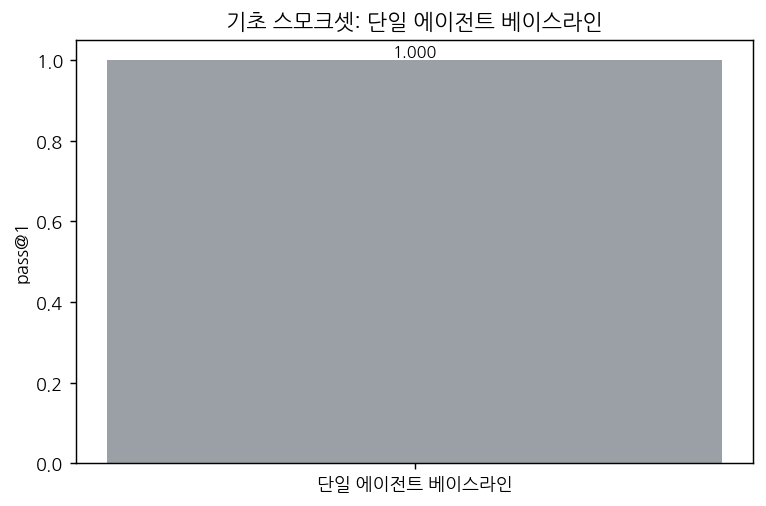

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/00_baseline_smoke.png


PosixPath('/Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/00_baseline_smoke.png')

In [12]:
from common import plotting  # noqa: E402

# 막대 하나짜리 그림이지만, 이후 모든 노트북이 같은 함수로 A/B 를 그린다.
# 같은 축, 같은 스케일로 그려야 눈으로 비교할 수 있기 때문이다.
plotting.ab_bar(
    "00_baseline_smoke",
    labels=["단일 에이전트 베이스라인"],
    values=[pass1],
    ylabel="pass@1",
    title="기초 스모크셋: 단일 에이전트 베이스라인",
)
